In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"timscientia","key":"3e9002fab0a8dd7709e254a4028ddc77"}'}

In [2]:
# membuat folder kaggle
! mkdir ~/.kaggle

# menyalin kaggle. json ke  folder yang sudah dibuat
! cp kaggle.json ~/.kaggle/

# menginzinkan json dapat membaca dan menulis isinya
! chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle competitions download -c big-data-competition-statistics-explore-2024

 97% 636M/655M [00:04<00:00, 183MB/s]
100% 655M/655M [00:05<00:00, 135MB/s]


In [4]:
!unzip big-data-competition-statistics-explore-2024

Output streaming akan dipotong hingga 5000 baris terakhir.
  inflating: Train Data/Train Data/None/Train Data (1991).jpg  
  inflating: Train Data/Train Data/None/Train Data (1992).jpg  
  inflating: Train Data/Train Data/None/Train Data (1993).jpg  
  inflating: Train Data/Train Data/None/Train Data (1994).jpg  
  inflating: Train Data/Train Data/None/Train Data (1995).jpg  
  inflating: Train Data/Train Data/None/Train Data (1996).jpg  
  inflating: Train Data/Train Data/None/Train Data (1997).jpg  
  inflating: Train Data/Train Data/None/Train Data (1998).jpg  
  inflating: Train Data/Train Data/None/Train Data (1999).jpg  
  inflating: Train Data/Train Data/None/Train Data (2).jpg  
  inflating: Train Data/Train Data/None/Train Data (20).jpg  
  inflating: Train Data/Train Data/None/Train Data (200).jpg  
  inflating: Train Data/Train Data/None/Train Data (2000).jpg  
  inflating: Train Data/Train Data/None/Train Data (2001).jpg  
  inflating: Train Data/Train Data/None/Train Data 

In [5]:
import os
HOME = os.getcwd()
print(HOME)

!mkdir {HOME}/datasets
%cd {HOME}/datasets

/content
/content/datasets


In [6]:
import pandas as pd
import os
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import shutil
import random
from tqdm import tqdm
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Dropout, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [7]:
def create_directories(base_path):
    for folder in ['train', 'validation', 'test']:
        for subfolder in ['Fire', 'None', 'Smoke', 'Smoke and Fire']:
            os.makedirs(os.path.join(base_path, folder, subfolder), exist_ok=True)

In [8]:
def copy_images(images, src_dir, dst_dir):
    for img in tqdm(images, desc=f"Copying to {dst_dir}"):
        src = os.path.join(src_dir, img)
        dst = os.path.join(dst_dir, img)
        try:
            shutil.copy2(src, dst)
        except Exception as e:
            print(f"Error copying {src} to {dst}: {e}")

In [9]:
def split_data(source_dir, dest_dir, split_ratio=(0.8, 0.1, 0.1)):
    classes = ['Fire', 'None', 'Smoke', 'Smoke and Fire']

    for class_name in classes:
        class_dir = os.path.join(source_dir, class_name)

        if not os.path.exists(class_dir):
            print(f"Warning: Directory {class_dir} does not exist. Skipping.")
            continue

        images = os.listdir(class_dir)
        if len(images) == 0:
            print(f"Warning: No images found in {class_dir}. Skipping.")
            continue

        random.shuffle(images)

        total_images = len(images)
        train_split = int(split_ratio[0] * total_images)
        validation_split = int(split_ratio[1] * total_images)

        train_images = images[:train_split]
        validation_images = images[train_split:train_split + validation_split]
        test_images = images[train_split + validation_split:]

        copy_images(train_images, class_dir, os.path.join(dest_dir, 'train', class_name))
        copy_images(validation_images, class_dir, os.path.join(dest_dir, 'validation', class_name))
        copy_images(test_images, class_dir, os.path.join(dest_dir, 'test', class_name))

source_directory = "/content/Train Data/Train Data"
destination_directory = "/content/datasets"
create_directories(destination_directory)
split_data(source_directory, destination_directory)

Copying to /content/datasets/test/Smoke: 100%|██████████| 31/31 [00:00<00:00, 3336.33it/s]
Copying to /content/datasets/train/Smoke and Fire: 100%|██████████| 2172/2172 [00:01<00:00, 1934.42it/s]
Copying to /content/datasets/validation/Smoke and Fire: 100%|██████████| 271/271 [00:00<00:00, 2672.53it/s]
Copying to /content/datasets/test/Smoke and Fire: 100%|██████████| 272/272 [00:00<00:00, 2511.02it/s]


In [10]:
def count_items_in_directory(directory):
    return sum([len(files) for _, _, files in os.walk(directory)])

def count_items(base_path):
    categories = ['train', 'validation', 'test']
    classes = ['Fire', 'None', 'Smoke', 'Smoke and Fire']

    for category in categories:
        print(f"--- {category.capitalize()} Data ---")
        category_path = os.path.join(base_path, category)
        for class_name in classes:
            class_path = os.path.join(category_path, class_name)
            if os.path.exists(class_path):
                num_items = count_items_in_directory(class_path)
                print(f"{class_name.capitalize()}: {num_items} images")
            else:
                print(f"{class_name.capitalize()}: Directory does not exist")

base_path = '/content/datasets'
count_items(base_path)

--- Train Data ---
Fire: 984 images
None: 2466 images
Smoke: 242 images
Smoke and fire: 2172 images
--- Validation Data ---
Fire: 123 images
None: 308 images
Smoke: 30 images
Smoke and fire: 271 images
--- Test Data ---
Fire: 123 images
None: 309 images
Smoke: 31 images
Smoke and fire: 272 images


In [11]:
def remove_invalid_images(directory):
    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                print(f"Menghapus file yang rusak: {file_path}")
                os.remove(file_path)

# Periksa dan hapus gambar tidak valid
for directory in ['/content/datasets/train', '/content/datasets/validation', '/content/datasets/test']:
    remove_invalid_images(directory)

Menghapus file yang rusak: /content/datasets/train/Smoke and Fire/Train Data (838).jpg


In [12]:
train_datagen = ImageDataGenerator(rescale = 1./255.,
                                   rotation_range = 40,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale=1./255.)

In [13]:
# Membangun ImageDataGenerators
train_generator = train_datagen.flow_from_directory(
    '/content/datasets/train',
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    '/content/datasets/validation',
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    '/content/datasets/test',
    target_size=(224, 224),
    batch_size=20,
    class_mode='categorical'
)

Found 5863 images belonging to 4 classes.
Found 732 images belonging to 4 classes.
Found 735 images belonging to 4 classes.


In [14]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [15]:
# Memuat model EfficientNetB0 tanpa layer atas (top layer) dan dengan input size yang sesuai
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Menambahkan lapisan tambahan di atas model dasar (base model)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)  # Lapisan Dense untuk menambahkan kapasitas model
predictions = Dense(train_generator.num_classes, activation='softmax')(x)  # Output layer dengan softmax untuk klasifikasi

In [17]:
# Membuat model akhir
model = Model(inputs=base_model.input, outputs=predictions)

In [18]:
# Mengkompilasi model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
# Melihat ringkasan model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling (Rescaling)     │ (None, 224, 224, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization             │ (None, 224, 224, 3)    │              7 │ rescaling[0][0]        │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_1 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_1[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_expand    

 Total params: 5,365,415 (20.47 MB)

 Trainable params: 5,323,392 (20.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [25]:
# Melatih model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size
)

Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1747s 6s/step - accuracy: 0.8257 - loss: 0.4271 - val_accuracy: 0.4556 - val_loss: 2.7614
Epoch 2/10
  1/293 ━━━━━━━━━━━━━━━━━━━━ 23:55 5s/step - accuracy: 0.8000 - loss: 0.3741

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8000 - loss: 0.3741 - val_accuracy: 0.8333 - val_loss: 0.7162
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1733s 6s/step - accuracy: 0.8291 - loss: 0.4031 - val_accuracy: 0.8347 - val_loss: 0.3906
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9000 - loss: 0.2745 - val_accuracy: 0.7500 - val_loss: 0.3301
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1740s 6s/step - accuracy: 0.8408 - loss: 0.3696 - val_accuracy: 0.7681 - val_loss: 0.5519
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8500 - loss: 0.2922 - val_accuracy: 1.0000 - val_loss: 0.1076
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1743s 6s/step - accuracy: 0.8545 - loss: 0.3519 - val_accuracy: 0.8083 - val_loss: 0.4053
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9000 - loss: 0.2189 - val_accuracy: 0.8333 - val_loss: 0.3631
Epoch 9/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 1726s 6s/step - accuracy: 0.8477 - loss: 0.3568 - val_accuracy: 0.794

In [26]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')

37/37 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.7871 - loss: 0.5995
Test accuracy: 0.7836734652519226


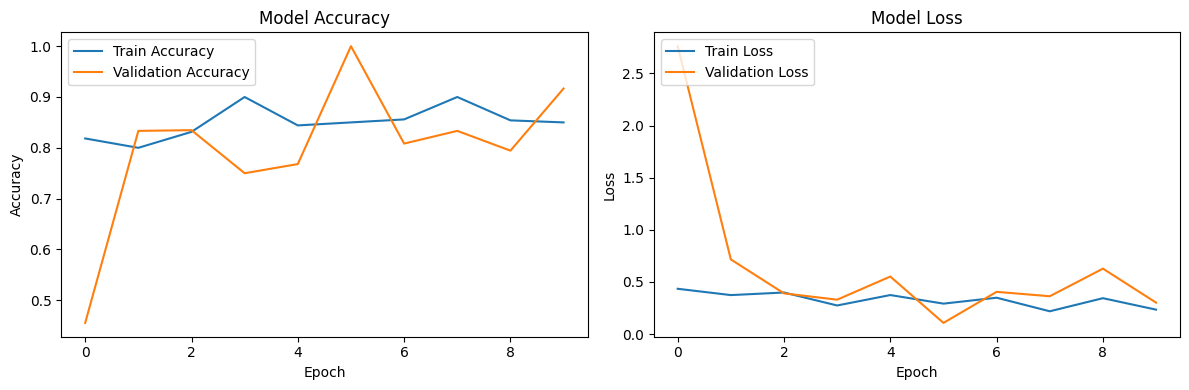

In [27]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

37/37 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step


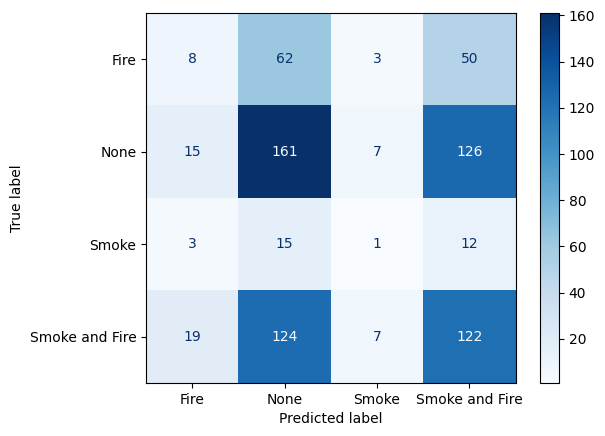

In [28]:
# Get the true labels and predictions
test_labels = test_generator.classes
predictions = model.predict(test_generator)
predicted_classes = predictions.argmax(axis=-1)

# Compute confusion matrix
cm = confusion_matrix(test_labels, predicted_classes, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fire', 'None', 'Smoke', 'Smoke and Fire'])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [24]:
print(classification_report(test_labels, predicted_classes, target_names=['Fire', 'None', 'Smoke', 'Smoke and Fire']))

                precision    recall  f1-score   support

          Fire       0.00      0.00      0.00       123
          None       0.42      1.00      0.59       309
         Smoke       0.00      0.00      0.00        31
Smoke and Fire       0.00      0.00      0.00       272

      accuracy                           0.42       735
     macro avg       0.11      0.25      0.15       735
  weighted avg       0.18      0.42      0.25       735



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


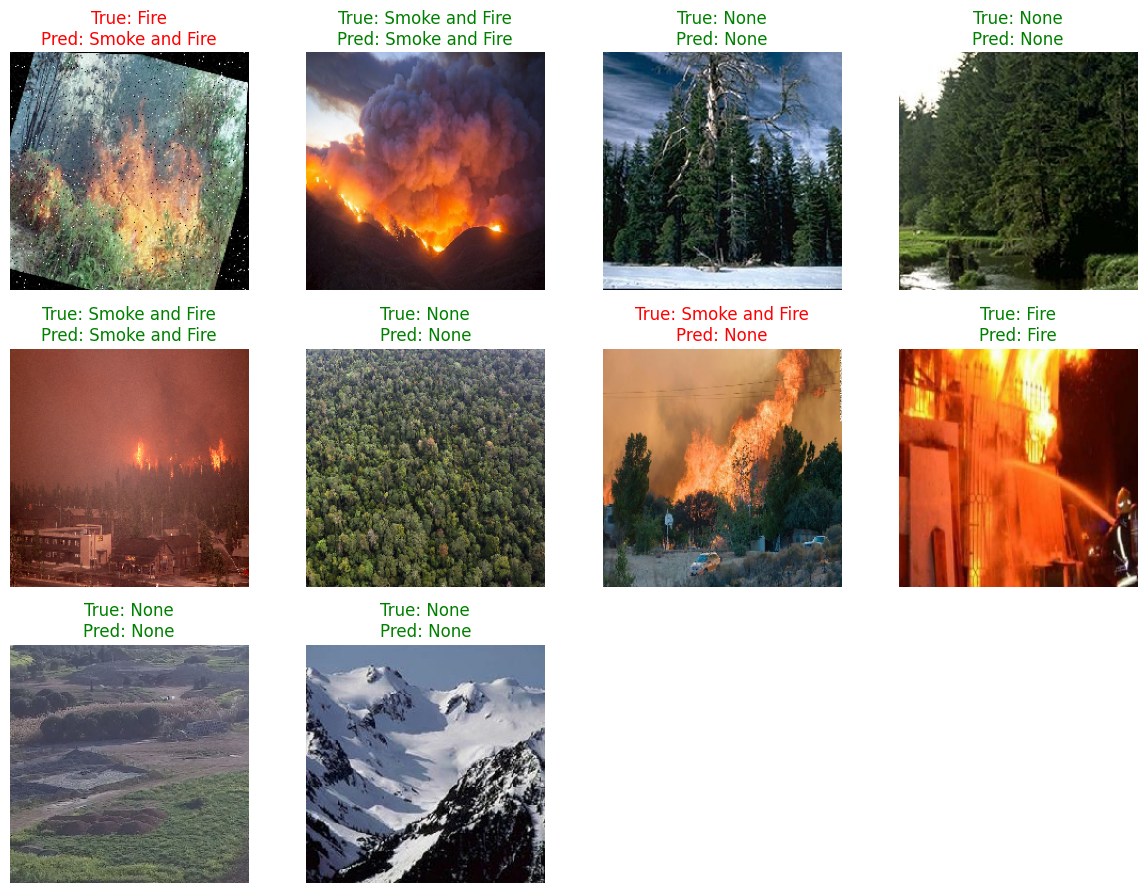

In [29]:
# Mendapatkan nama kelas dari generator
class_names = list(test_generator.class_indices.keys())

# Ambil satu batch gambar dari test_generator
test_images, test_labels = next(test_generator)
predictions = model.predict(test_images)
predicted_classes = predictions.argmax(axis=-1)

# Menampilkan gambar dengan label asli dan prediksi
plt.figure(figsize=(12, 12))
for i in range(10):  # Menampilkan 9 gambar pertama
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i])
    true_label = class_names[np.argmax(test_labels[i])]
    predicted_label = class_names[predicted_classes[i]]
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color="green" if true_label == predicted_label else "red")
    plt.axis('off')
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


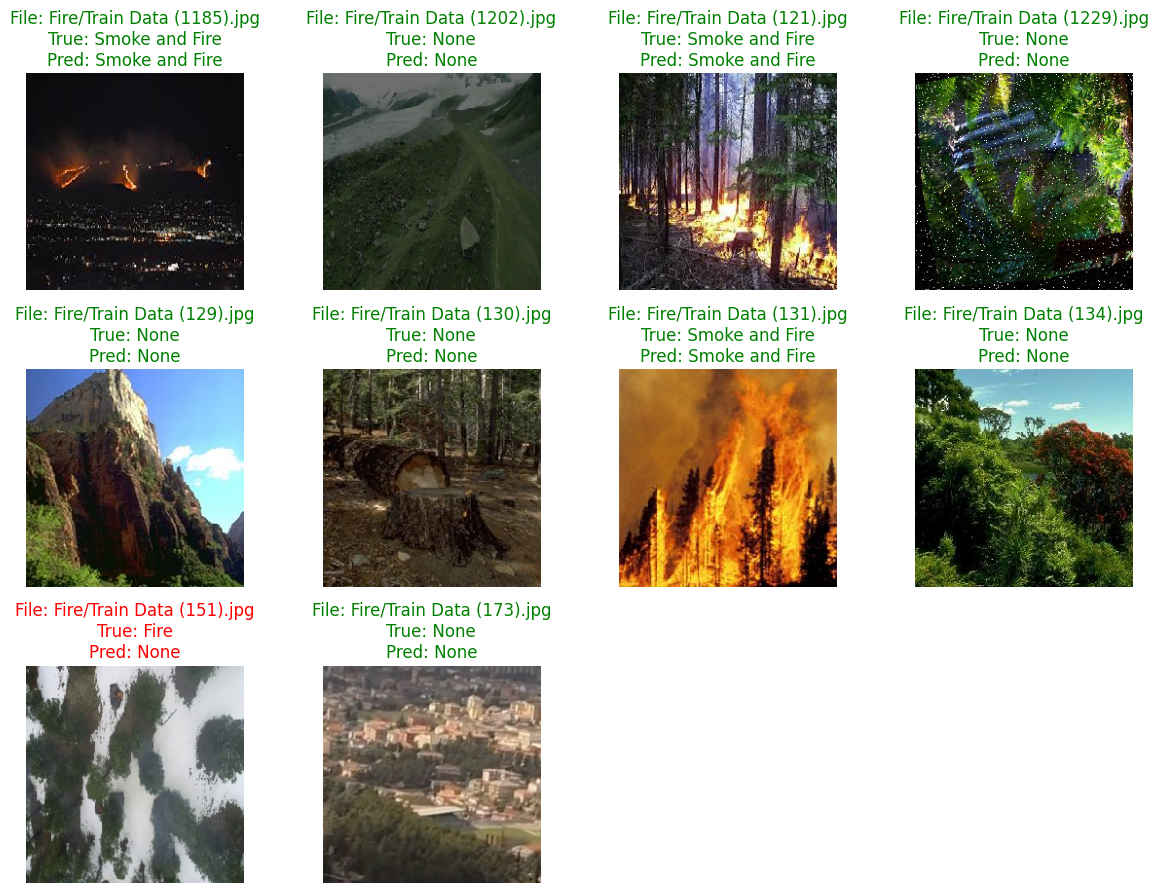

In [30]:
# Mendapatkan nama kelas dari generator
class_names = list(test_generator.class_indices.keys())

# Ambil satu batch gambar dari test_generator
test_images, test_labels = next(test_generator)
predictions = model.predict(test_images)
predicted_classes = predictions.argmax(axis=-1)

# Mendapatkan daftar semua file di test_generator
test_filenames = np.array(test_generator.filenames)
batch_size = test_generator.batch_size

# Menghitung indeks dari file yang ditampilkan
current_index = test_generator.batch_index * batch_size
start_index = current_index - batch_size
if start_index < 0:
    start_index = 0

# Mengambil nama file untuk batch saat ini
batch_filenames = test_filenames[start_index:current_index]

# Menampilkan gambar dengan label asli, prediksi, dan nama file
plt.figure(figsize=(12, 12))
for i in range(10):  # Menampilkan 10 gambar pertama
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_images[i])
    true_label = class_names[np.argmax(test_labels[i])]
    predicted_label = class_names[predicted_classes[i]]
    filename = batch_filenames[i]
    plt.title(f"File: {filename}\nTrue: {true_label}\nPred: {predicted_label}",
              color="green" if true_label == predicted_label else "red")
    plt.axis('off')
plt.tight_layout()
plt.show()


17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 836ms/step


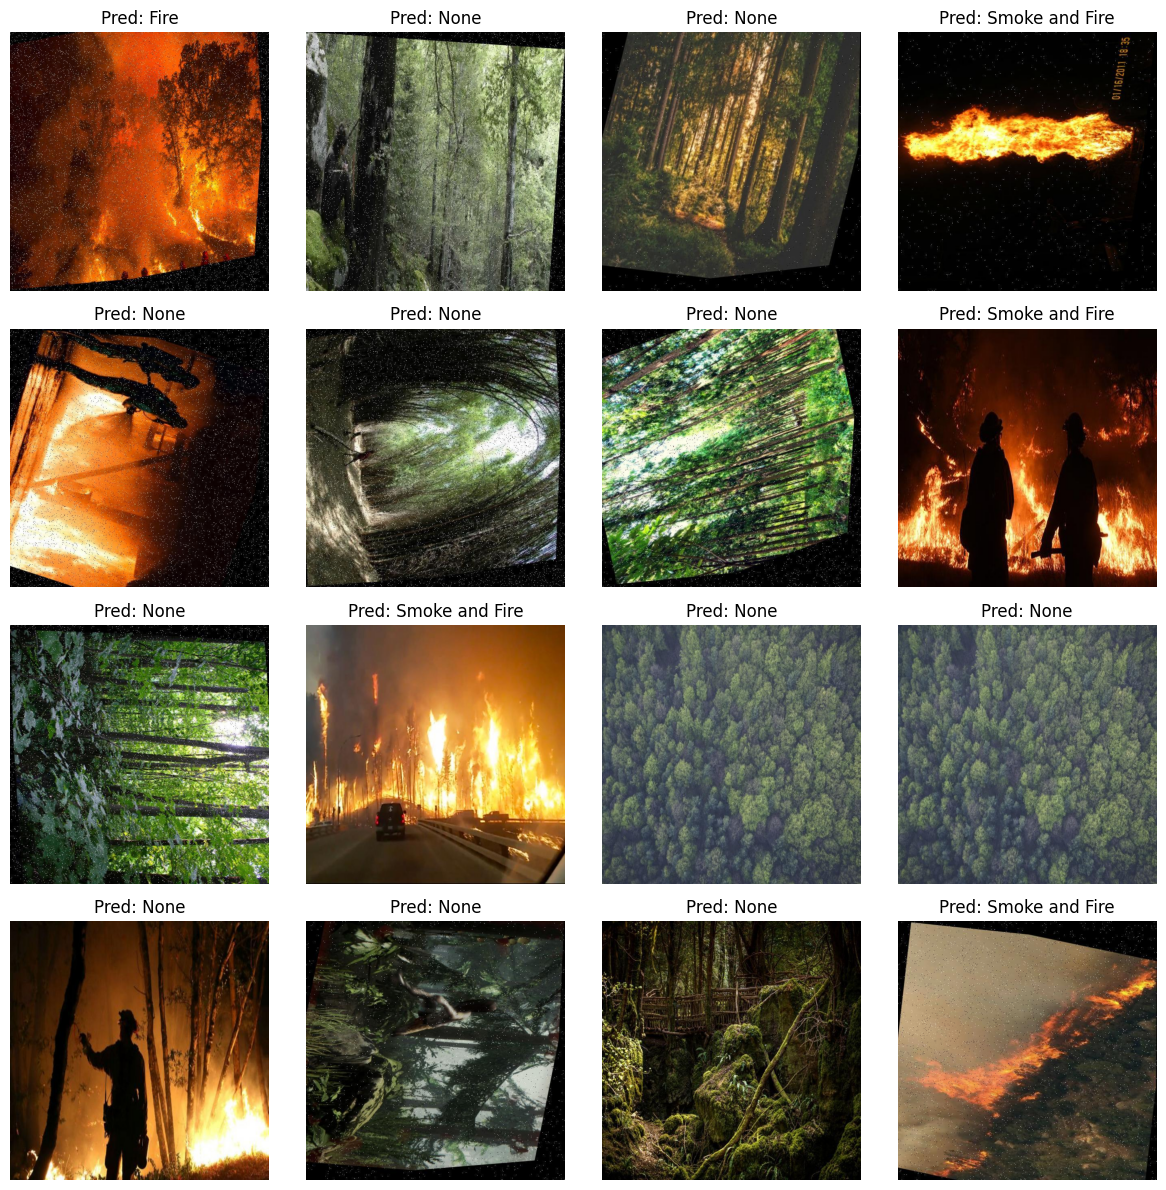

In [31]:
#MEMPREDIKSI DATA "TEST DATA"

# Path ke folder gambar yang ingin diprediksi
folder_path = '/content/Test Data/TEST BDC FIX WITH ACAK'

# Daftar nama kelas dari model (sesuaikan dengan nama kelas model Anda)
class_names = ['Fire', 'None', 'Smoke', 'Smoke and Fire']

# Fungsi untuk memuat dan memproses gambar
def load_and_process_image(image_path):
    img = image.load_img(image_path, target_size=(150, 150))  # Sesuaikan ukuran dengan input model
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  # Normalisasi
    return img_array

# Muat semua gambar dari folder
image_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith('.jpg')]
test_images = np.array([load_and_process_image(path) for path in image_paths])

# Buat batch data untuk prediksi
batch_size = 32
test_generator = tf.data.Dataset.from_tensor_slices(test_images).batch(batch_size)

# Buat prediksi dengan model
predictions = model.predict(test_generator)
predicted_classes = predictions.argmax(axis=-1)

# Tampilkan hasil prediksi
max_images_to_display = 16  # Batasi jumlah gambar yang ditampilkan
num_images = min(len(image_paths), max_images_to_display)

plt.figure(figsize=(12, 12))
for i in range(num_images):
    plt.subplot(4, 4, i + 1)
    img = image.load_img(image_paths[i])
    plt.imshow(img)
    predicted_label = class_names[predicted_classes[i]]
    plt.title(f"Pred: {predicted_label}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [32]:
results = {
    'Id': [os.path.splitext(os.path.basename(path))[0] for path in image_paths],  # Menghapus ekstensi .jpg
    'Prediction': [class_names[predicted_class] for predicted_class in predicted_classes]
}
misi = pd.DataFrame(results)

submission_file_path = '/content/datasets/predictions.csv'
misi.to_csv(submission_file_path, index=False)

existing_submission_file_path = '/content/sample_submission.csv'
existing_df = pd.read_csv(existing_submission_file_path, keep_default_na=False, na_values=['']).fillna('None')
new_df = pd.read_csv(submission_file_path, keep_default_na=False, na_values=['']).fillna('None')


# Concat file csv
combined_df = existing_df[['Id']].merge(new_df, on='Id', how='left')
output_file_path = '/content/datasets/Submission.csv'
combined_df.to_csv(output_file_path, index=False)

print(f'file {output_file_path} Berhasil di Concat')

# Menggabungkan data berdasarkan 'Id'
combined_df = existing_df[['Id']].merge(new_df, on='Id', how='left')

category_mapping = {'None': 1,'Fire': 2,'Smoke': 3,'Smoke and Fire': 4 }

# Mengganti nama kelas di kolom 'Prediction' dengan angka yang sesuai
combined_df['Prediction'] = combined_df['Prediction'].map(category_mapping).fillna(1).astype(int)
output_file_path = '/content/datasets/Submission_FIX.csv'
combined_df.to_csv(output_file_path, index=False)

print(f'File {output_file_path} berhasil di-concat dan diperbarui')

file /content/datasets/Submission.csv Berhasil di Concat
File /content/datasets/Submission_FIX.csv berhasil di-concat dan diperbarui
